In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, ncx2

Let's try a toy example with three parameters ($a, b, c$), and two harmonics ($h_0, h_1$). Let's treat both harmonics at having peaks at the true values of the parameters, and with noise affecting both harmonics (independently) in the same way. We will also assume that a mismatch of 0.01 corresponds to a change of 1 in any single parameter.

In [4]:
true_params = {'a': 5}
true_snrs = {0: 10+0j, 1: 3+3j}

In [5]:
def find_two_harm_peak(true_params, true_snrs, npts=10**5):

    # Draw random observed snrs
    obs_snrs = {k: np.random.normal(0, 1, npts) + 1j*np.random.normal(0, 1, npts) + true_snrs[k] for k in true_snrs.keys()}

    # Draw random parameter peaks in each harmonic
    obs_params = {}
    evec_sizes = {}
    norm = 0.01
    n_sigma = np.sqrt(chi2.isf(1 - 0.9, len(true_params)))
    for k in obs_snrs.keys():
        mismatch = n_sigma ** 2 / (2 * np.abs(obs_snrs[k]) ** 2)
        evec_sizes[k] = np.sqrt(mismatch/norm)
        obs_params[k] = {j: true_params[j] + np.random.normal(0, 1, npts)*evec_sizes[k]/n_sigma for j in true_params.keys()}

    # Find combined peak point
    diffsq = 0
    for j in obs_params[0].keys():
        diffsq += np.abs(obs_params[0][j] - obs_params[1][j])**2
    peak_diff = np.sqrt(diffsq)
    n = norm
    x = peak_diff
    rho_0 = np.abs(obs_snrs[0])
    rho_1 = np.abs(obs_snrs[1])
    p3s = n*x**2*(rho_0**2+rho_1**2)
    p2s = -3*n*x**2*rho_1**2
    p1s = 3*n*x**2*rho_1**2 - (rho_0**2+rho_1**2)
    p0s = (1-n*x**2)*rho_1**2
    alpha = np.zeros(npts)
    for i, (p3, p2, p1, p0) in enumerate(zip(p3s, p2s, p1s, p0s)):
        roots = np.roots([p3,p2,p1,p0])
        above_zero = roots>=0
        below_one = roots<=1
        real = np.imag(roots)==0
        alpha[i] = np.abs(roots[above_zero*below_one*real])[0]
    invalid_inds = p3*alpha**3 + p2*alpha**2 + p1*alpha + p0 < np.max([rho_0**2, rho_1**2], axis=0)
    alpha[invalid_inds] = np.argmax([rho_0**2, rho_1**2], axis=0)[invalid_inds]
    comb_point = {j: obs_params[0][j] + alpha*(obs_params[1][j]-obs_params[0][j]) for j in true_params.keys()}
    zero_comb_snr = np.abs(obs_snrs[0])*(1-n*alpha**2*x**2)**2
    one_comb_snr = np.abs(obs_snrs[1])*(1-n*(1-alpha)**2*x**2)**2
    
    return comb_point, zero_comb_snr, one_comb_snr

We will calculate the observed snrs in each harmonics, and use this to draw a random observed peak param in each harmonic. We can then add the distributions together to find the observed peak param in both harmonics (where the joint observed snr is highest).

$$
\rho_k (a,b,c) = \rho_{k,\mathrm{obs}}\cdot \left(1 - mm(a,b,c)\right)
$$

$$
\rho_k (a,b,c) = \rho_{k,\mathrm{obs}}\cdot \left(1 - n\cdot\left[(a-a_k)^2 + (b-b_k)^2 + (c-c_k)^2\right]\right)
$$

We then sum the snrs in quadrature, so we want to maximise the quantity $\rho_0^2 + \rho_1^2$

$$
\rho_0^2 + \rho_1^2 = \rho_{0,\mathrm{obs}}^2 \cdot \left(1 - n\cdot\left[(a-a_0)^2 + (b-b_0)^2 + (c-c_0)^2\right]\right)^2 + \rho_{1,\mathrm{obs}}^2 \cdot \left(1 - n\cdot\left[(a-a_1)^2 + (b-b_1)^2 + (c-c_1)^2\right]\right)^2
$$

We know that the maximum point will lie on a line between the two harmonic peaks.

$$
\rho_0^2 + \rho_1^2 = \rho_{0,\mathrm{obs}}^2 \cdot \left(1 - n\cdot x_0^2\right)^2 + \rho_{1,\mathrm{obs}}^2 \cdot \left(1 - n\cdot x_1^2\right)^2
$$

$$
\rho_0^2 + \rho_1^2 = \rho_{0,\mathrm{obs}}^2 \cdot \left(1 - 2n \cdot x_0^2 + n^2 x_0^4\right) + \rho_{1,\mathrm{obs}}^2 \cdot \left(1 - 2n \cdot x_1^2 + n^2 x_1^4\right)
$$

We can parameterise this as
$$
x_0 = \alpha x, x_1 = (1-\alpha) x
$$

$$
\rho_0^2 + \rho_1^2 = \rho_{0,\mathrm{obs}}^2 \left(1 - 2n  \alpha^2 x^2 + n^2 \alpha^4 x^4\right) + \rho_{1,\mathrm{obs}}^2  \left(1 - 2n  (1-\alpha)^2 x^2 + n^2 (1-\alpha)^4 x^4\right)
$$

Differentiate with respect to $\alpha$

$$
-4n \alpha x^2 \rho_{0,\mathrm{obs}}^2 + 4n^2 \alpha^3 x^4 \rho_{0,\mathrm{obs}}^2 + 4n(1-\alpha)x^2\rho_{1,\mathrm{obs}}^2 - 4n^2(1-\alpha)^3 x^4\rho_{1,\mathrm{obs}}^2 = 0
$$

$$
-\alpha \rho_{0,\mathrm{obs}}^2 + n \alpha^3 x^2 \rho_{0,\mathrm{obs}}^2 + (1-\alpha)\rho_{1,\mathrm{obs}}^2 - n(1-\alpha)^3 x^2\rho_{1,\mathrm{obs}}^2 = 0
$$

$$
-\alpha \rho_{0,\mathrm{obs}}^2 + n \alpha^3 x^2 \rho_{0,\mathrm{obs}}^2 + \rho_{1,\mathrm{obs}}^2 - \alpha \rho_{1,\mathrm{obs}}^2  - n x^2\rho_{1,\mathrm{obs}}^2 + 3n\alpha x^2\rho_{1,\mathrm{obs}}^2 - 3n \alpha^2 x^2\rho_{1,\mathrm{obs}}^2 + n \alpha^3 x^2\rho_{1,\mathrm{obs}}^2 = 0
$$

$$
\alpha^3 [nx^2(\rho_{0,\mathrm{obs}}^2+\rho_{1,\mathrm{obs}}^2)] + \alpha^2 [-3nx^2\rho_{1,\mathrm{obs}}^2] + \alpha[3nx^2\rho_{1,\mathrm{obs}}^2 - (\rho_{0,\mathrm{obs}}^2+\rho_{1,\mathrm{obs}}^2)] + [(1-nx^2)\rho_{1,\mathrm{obs}}^2] = 0
$$

In [6]:
def get_dist_dx(true_params, comb_point, zero_comb_snr):

    # Get unnormalised distance to true parameters
    distsq = 0
    for j in true_params.keys():
        distsq += (true_params[j] - comb_point[j])**2
    dist = np.sqrt(distsq)

    # Find normalised distances
    norm = 0.01
    n_sigma = np.sqrt(chi2.isf(1 - 0.9, len(true_params)))
    mismatch = n_sigma ** 2 / (2 * np.abs(zero_comb_snr) ** 2)
    evec_size = np.sqrt(mismatch/norm)
    dist /= evec_size

    return dist

In [7]:
comb_point, zero_comb_snr, one_comb_snr = find_two_harm_peak(true_params, true_snrs, npts=10**5)
dist_dx = get_dist_dx(true_params, comb_point, zero_comb_snr)
# dist_dx = get_dist_dx(true_params, comb_point, np.sqrt(zero_comb_snr**2+one_comb_snr**2))

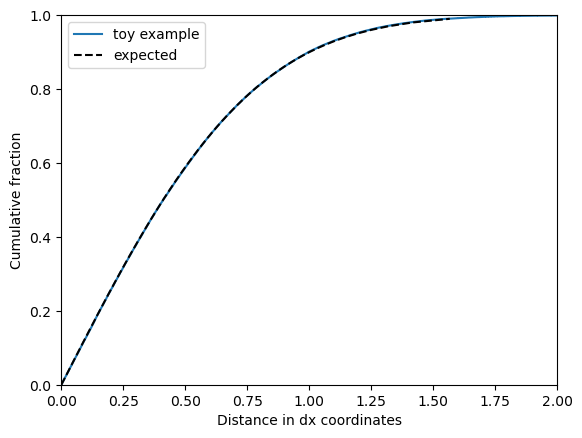

In [8]:
sorted_dists = np.sort([*dist_dx, np.max(dist_dx)+10**-9])
plt.step(sorted_dists, np.arange(len(sorted_dists))/len(dist_dx), label='toy example')
probs = np.linspace(0, 1, 101)
dx_dist_exp = (ncx2.ppf(probs, len(true_params), 0)/ncx2.ppf(0.9, len(true_params), 0))**0.5
plt.plot(dx_dist_exp, probs, c='k', ls='dashed', label='expected')
plt.xlim(0, 2)
plt.ylim(0, 1)
plt.xlabel('Distance in dx coordinates')
plt.ylabel('Cumulative fraction')
plt.legend()